# **SIMULATION**

### 1. Problem Setup

Let us discuss the mathematical setup of the problem in a fair amount of mathematical detail.

### 2. Simulation Data

We now visualise the simulation data provided by Mouad. Firstly, we important all required modules and load the data,

In [1]:
# Dependencies,
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation

# Loading the simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = file["t"][:]
    u = file["u"][:]
    v = file["v"][:]
    p = file["p"][:]
    x = file["x"][:]
    y = file["y"][:]

Inspecting the our time values `t`, we confirm that we have `201` time steps that range from `t=400` to `t=420`. Each step represents `0.1` units of time. Moreover, we have `82,872` number of nodes which take one a value of $u$, $v$ and $p$ at a given time $t$. Let us now visualise the velocity field for a given time $t$,

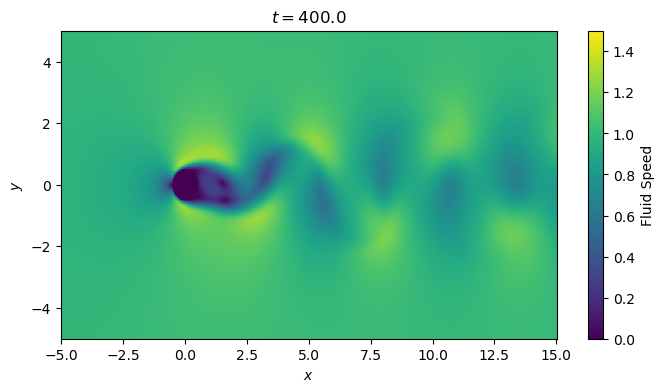

In [8]:
def compute_speed_grid(u, v, p, x, y, t, time_idx=0, padding=0.25, grid_res=(500, 500), region = (-5, 15, -5, 5)):
    """Computes the speed grid and returns it along with the mesh grid when supplied with the simulation
    data."""

    # Extracting temporal snapshot,
    u_snap, v_snap, p_snap, x_snap, y_snap, t_snap = u[time_idx], v[time_idx], p[time_idx], x[time_idx], y[time_idx], t[time_idx]

    # Selecting region of interest,
    x_min, x_max, y_min, y_max = region[0], region[1], region[2], region[3]

    # Applying boolean mask,
    bool_mask = (x_snap >= x_min-padding) & (x_snap <= x_max+padding) & (y_snap >= y_min-padding) & (y_snap <= y_max+padding) 
    u_snap, v_snap, p_snap, x_snap, y_snap = u_snap[bool_mask], v_snap[bool_mask], p_snap[bool_mask], x_snap[bool_mask], y_snap[bool_mask]

    # Computing the speed (scalar field),
    speed = np.sqrt(u_snap**2 + v_snap**2)

    # Creating mesh grid,
    nx, ny = grid_res # <-- grid resolution.
    xi = np.linspace(start=x_min, stop=x_max, num=nx)
    yi = np.linspace(start=y_min, stop=y_max, num=ny)
    X_grid, Y_grid = np.meshgrid(xi, yi)

    # Interpolation (creating speed and pressure grids),
    speed_grid = griddata(
        points=np.column_stack([x_snap, y_snap]),
        values=speed,
        xi=(X_grid, Y_grid),
        method='cubic'
    )

    return speed_grid, t_snap, X_grid, Y_grid

# Computing speed grid (initial time),
speed_grid, t_snap, X_grid, Y_grid = compute_speed_grid(u, v, p, x, y, t, time_idx=0)

# Plotting,
plt.figure(figsize=(8, 4))
plt.pcolormesh(X_grid, Y_grid, speed_grid, shading="auto", cmap="viridis", vmin=0, vmax=1.5)
plt.colorbar(label="Fluid Speed")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(f"$t={t_snap}$")
plt.show()

Now we create an animation,

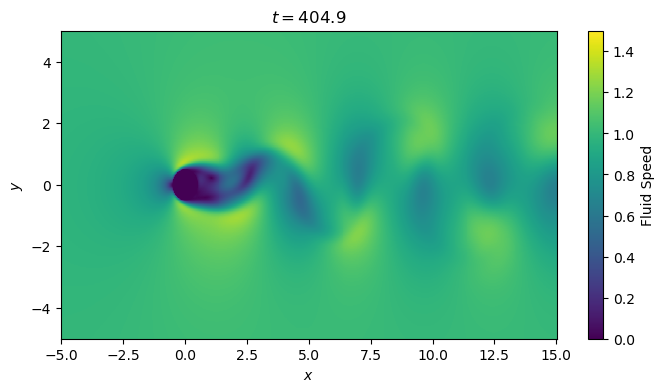

In [12]:
def update_frame(frame):
    global mesh, title
    speed_grid, t_snap, _, _ = compute_speed_grid(u, v, p, x, y, t, time_idx=frame)
    mesh.set_array(speed_grid.ravel())
    title.set_text(f"$t = {t_snap}$")
    return mesh, title

# Creating figure,
fig, ax = plt.subplots(figsize=(8, 4))
speed_grid_init, t_0, X_grid, Y_grid = compute_speed_grid(u, v, p, x, y, t, time_idx=0)
mesh = ax.pcolormesh(X_grid, Y_grid, speed_grid_init, shading="auto", cmap="viridis", vmin=0, vmax=1.5)
fig.colorbar(mesh, label="Fluid Speed")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
title = ax.set_title(f"$t = {t_0}$")

# Constucting animation,
ani = FuncAnimation(fig=fig,
                    func=update_frame,
                    frames=50,
                    interval=100,
                    blit=True)

# Saving animation,
ani.save("fluid_flow.mp4", writer="ffmpeg", fps=10)

There are a few things to consider when creating the animation. There are `200` snapshots (including the snapshot of the initial state of the system) which begin from the intial time `t=400` to final time of `t=420`. Assuming that the units of time are seconds, the time between each snapshot or frame is `100 ms` which corresponds to `10` FPS. To create the animation, we only consider `5` of the `20` seconds of the simulation. Considering that it takes approximately `4 s` to generate a single frame/snapshot on my computer, it will take around three minutes to render this animation.

# References


Numerical simulation data of a two-dimensional flow around a fixed circular cylinder. Boudina (2021). URL: https://zenodo.org/records/5039610?utm_source=chatgpt.com 
